# Streaming offline audio to simulate real-time audio tagging

## Creating synthetic audio

First let's create an audio sample to work with. I won't go into details about the math behind the waveform.

In [13]:
import numpy as np
from scipy.io.wavfile import write

# Parameters
sample_rate = 16000  # Hz
duration = 15.0       # seconds
frequency = 440.0    # A4 note, Hz

t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

waveform = 0.5 * np.sin(2 * np.pi * frequency * t) * (1 + 0.3 * np.sin(2 * np.pi * 2 * t))

# Convert to 16-bit PCM
audio = np.int16(waveform / np.max(np.abs(waveform)) * 32767)

Let's visualize the waveform

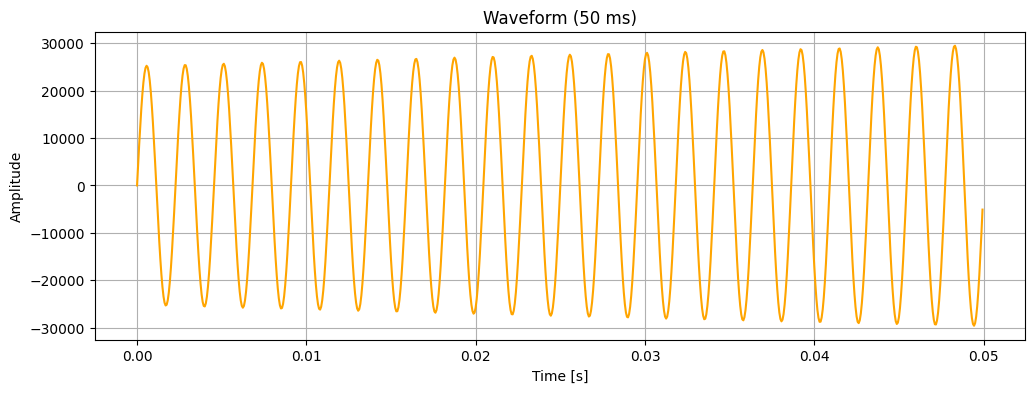

In [14]:
import matplotlib.pyplot as plt

# Time axis in seconds
t = np.arange(len(audio)) / sample_rate

zoom_samples = int(0.05 * sample_rate)  # first 50 ms
plt.figure(figsize=(12, 4))
plt.plot(t[:zoom_samples], audio[:zoom_samples], color='orange')
plt.title("Waveform (50 ms)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


Let's also listen to this audio for reference.

In [15]:
from IPython.display import Audio

Audio(audio, rate=sample_rate)

## Streaming

Our problem setting is to take an audio recording (could be stored in a file) and process it as a *stream* that can be tagged with an *audio tagger*.

In this setting, when we say we want *streaming*, we mean: "I want my system to behave as if audio is arriving live, even though it’s coming from a file."

When we say we want an *audio tagger*, we mean: "I want my system to be a model that can take as input a piece of audio (whether that be as an embedding or another compression) and can classify what that audio piece is."

This implies three constraints:

- Causality: future samples stay hidden with no knowledge of them
- Time alignment: audio processing must be close-to or on par with a real-time clock
- Incremental inference: our model sees overlapping overtime


The buffer must:

- Always contain the most recent N samples
- Discard old samples automatically
- Trigger inference at fixed intervals

This is called a *ring buffer* or *sliding window* buffer.

There are three time scales to keep in mind.

1. Stream chunk -- to simulate the real-timeness aspect
2. Model window -- what the model actually takes as input
3. Hop size -- how often the model predicts/tags

Following from these scales, the **general streaming procedure** is to:

1. Read a small chunk of audio
2. Append chunk to buffer
    - if buffer is full:
       - check if hop interval elapsed
          - Yes? perform model inference
          
3. Wait a correct amount of real-time
4. Repeat

In [16]:
# Tagging model (you should replace with your own model)
def tag(window):
    print(f"Tag for: {window.shape}")

In [17]:
# Parameters
SR = 16000
CHUNK_SIZE = 512          # 512 samples / 16000 Hz = 32 ms
WINDOW_SIZE = SR * 4      # 4 seconds
HOP_SIZE = SR * 2         # 2 seconds

In [18]:
# Ring buffer
from collections import deque

buffer = deque(maxlen=WINDOW_SIZE)
samples_since_last_inference = 0

In [19]:
# Streaming loop
import soundfile as sf
import numpy as np
import time

chunk_duration = CHUNK_SIZE / SR
next_time = time.monotonic()

for start in range(0, len(audio), CHUNK_SIZE):
    chunk = audio[start:start + CHUNK_SIZE]
    
    # append to buffer
    buffer.extend(chunk)
    samples_since_last_inference += len(chunk)

    # run inference if window is ready & hop elapsed
    if len(buffer) == WINDOW_SIZE and samples_since_last_inference >= HOP_SIZE:
        samples_since_last_inference = 0
        window = np.array(buffer)
        tag(window)

    # enforce real-time
    next_time += chunk_duration
    sleep = next_time - time.monotonic()
    if sleep > 0:
        time.sleep(sleep)

Tag for: (64000,)
Tag for: (64000,)
Tag for: (64000,)
Tag for: (64000,)
Tag for: (64000,)
Tag for: (64000,)


Note that since our hop size was 2 seconds, the model predicts every 2 seconds and thus 7 tags.